In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb

In [30]:

# Update this path to where your file is
DATA_PATH = r"/Users/francisbateman/Desktop/Wadhams Start Up/Code/CL_VD_Data.xlsx"

# Load all sheets
cl_train = pd.read_excel(DATA_PATH, sheet_name='CL_imputated_training_dataset')
cl_eval  = pd.read_excel(DATA_PATH, sheet_name='CL_evaluation_dataset')
vd_train = pd.read_excel(DATA_PATH, sheet_name='VDss_imputated_training_dataset')
vd_eval  = pd.read_excel(DATA_PATH, sheet_name='VDss_evaluation_dataset')

print(f"CL  — train: {len(cl_train)}, eval: {len(cl_eval)}")
print(f"Vd  — train: {len(vd_train)}, eval: {len(vd_eval)}")
cl_train.head()

CL  — train: 695, eval: 46
Vd  — train: 706, eval: 45


,mol,NAME,human_CL_mL_min_kg,rat_CL_mL_min_kg,dog_CL_mL_min_kg,monkey_CL_mL_min_kg,human_fup,rat_fup,dog_fup,monkey_fup,pKa_Acid,pKa_base,water_solubility,Caco_2
0,FC=1C(=O)NC(=O)NC=1,5-Fluorouracil,26.000000,33.000000,2.478974,10.975391,0.6400,0.690000,0.821472,0.470259,7.76,-8.00,11.1000,0
1,S=C1N=CNc2nc[nH]c12,6-Mercaptopurine,15.000000,35.050968,14.689601,15.200000,0.8500,0.621611,0.689628,0.663784,9.50,2.99,68.5000,0
2,O(C)[C@@H]1[C@H](NC)C[C@H]2O[C@]1(C)n1c3c4n2c2...,7-Hydroxystaurosporine,0.000455,65.000000,10.200000,136.499160,0.0022,0.695361,0.007400,1.000000,7.42,9.56,0.0592,0
3,O=C1[C@](O)(CC)C2=C(C(=O)N3C(c4nc5c(c(N)ccc5)c...,9-Aminocamptothecin,6.500000,150.000000,6.914408,7.032731,0.0030,0.390427,0.592689,0.451104,11.71,3.91,0.6330,0
4,OC[C@@H]1C=C[C@H](n2c3nc(N)nc(NC4CC4)c3nc2)C1,Abacavir,13.000000,30.000000,3.222790,74.071304,0.5000,0.703922,0.683318,0.845847,15.41,5.77,77.0000,0


In [31]:

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import numpy as np

PHYSCHEM_COLS = ['human_fup', 'pKa_Acid', 'pKa_base', 'water_solubility', 'Caco_2']
CL_SPECIES_COLS = ['rat_CL_mL_min_kg', 'dog_CL_mL_min_kg', 'monkey_CL_mL_min_kg']
VD_SPECIES_COLS = ['rat_VDss_L_kg', 'dog_VDss_L_kg', 'monkey_VDss_L_kg']

RDKIT_DESCRIPTORS = [
    ('MolWt',            Descriptors.MolWt),
    ('MolLogP',          Descriptors.MolLogP),
    ('TPSA',             Descriptors.TPSA),
    ('NumHDonors',       Descriptors.NumHDonors),
    ('NumHAcceptors',    Descriptors.NumHAcceptors),
    ('NumRotatableBonds',Descriptors.NumRotatableBonds),
    ('NumAromaticRings', Descriptors.NumAromaticRings),
    ('NumAliphaticRings',Descriptors.NumAliphaticRings),
    ('NumHeavyAtoms',    Descriptors.HeavyAtomCount),
    ('RingCount',        Descriptors.RingCount),
    ('FractionCSP3',     Descriptors.FractionCSP3),
    ('MolMR',            Descriptors.MolMR),
    ('LabuteASA',        Descriptors.LabuteASA),
    ('BertzCT',          Descriptors.BertzCT),
    ('NumSaturatedRings',Descriptors.NumSaturatedRings),
]

def compute_rdkit_descriptors(mol):
    return np.array([fn(mol) for _, fn in RDKIT_DESCRIPTORS], dtype=float)

def smiles_to_features(df, smiles_col='mol', extra_cols=None, radius=2, nbits=2048):
    fps, tabular, valid_idx = [], [], []
    cols = PHYSCHEM_COLS + (extra_cols or [])
    for i, row in df.iterrows():
        mol = Chem.MolFromSmiles(str(row[smiles_col]))
        if mol is None:
            continue
        fp   = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits))
        rdkit_feats = compute_rdkit_descriptors(mol)
        tab  = row[cols].values.astype(float)
        tabular.append(np.concatenate([rdkit_feats, tab]))
        fps.append(fp)
        valid_idx.append(i)
    X = np.hstack([np.array(fps), np.array(tabular)])
    return X, valid_idx

In [32]:
# CL — include preclinical CL species data
X_cl_train, idx_cl_train = smiles_to_features(cl_train, extra_cols=CL_SPECIES_COLS)
X_cl_eval,  idx_cl_eval  = smiles_to_features(cl_eval,  extra_cols=CL_SPECIES_COLS)

# Vd — include preclinical Vd species data
X_vd_train, idx_vd_train = smiles_to_features(vd_train, extra_cols=VD_SPECIES_COLS)
X_vd_eval,  idx_vd_eval  = smiles_to_features(vd_eval,  extra_cols=VD_SPECIES_COLS)

# Log-transform targets
y_cl_train = np.log(cl_train.loc[idx_cl_train, 'human_CL_mL_min_kg'].values)
y_cl_eval  = np.log(cl_eval.loc[idx_cl_eval,   'human_CL_mL_min_kg'].values)
y_vd_train = np.log(vd_train.loc[idx_vd_train, 'human_VDss_L_kg'].values)
y_vd_eval  = np.log(vd_eval.loc[idx_vd_eval,   'human_VDss_L_kg'].values)

In [33]:


def train_and_evaluate(X_train, y_train, X_eval, y_eval, label):
    model = RandomForestRegressor(
        n_estimators=500,
        max_features='sqrt',
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    preds = model.predict(X_eval)
    rmse  = np.sqrt(mean_squared_error(y_eval, preds))
    r2    = r2_score(y_eval, preds)
    
    # Fold error (back-transformed) — standard PK metric
    fold_error = np.mean(np.abs(np.exp(preds) - np.exp(y_eval)) / np.exp(y_eval))
    
    print(f"\n{label} — Random Forest Results:")
    print(f"  RMSE (log scale): {rmse:.3f}")
    print(f"  R²:               {r2:.3f}")
    print(f"  Mean fold error:  {fold_error:.2f}x")
    
    return model, preds

cl_model, cl_preds = train_and_evaluate(
    X_cl_train, y_cl_train, X_cl_eval, y_cl_eval, "CL"
)
vd_model, vd_preds = train_and_evaluate(
    X_vd_train, y_vd_train, X_vd_eval, y_vd_eval, "Vd"
)
gmfe_cl = 10 ** np.mean(np.abs(np.log10(np.exp(cl_preds) / np.exp(y_cl_eval))))
gmfe_vd = 10 ** np.mean(np.abs(np.log10(np.exp(vd_preds) / np.exp(y_vd_eval))))
print(f"CL GMFE: {gmfe_cl:.2f}")
print(f"Vd GMFE: {gmfe_vd:.2f}")


CL — Random Forest Results:
  RMSE (log scale): 0.902
  R²:               0.508
  Mean fold error:  1.28x

Vd — Random Forest Results:
  RMSE (log scale): 0.583
  R²:               0.792
  Mean fold error:  0.63x
CL GMFE: 2.04
Vd GMFE: 1.62


In [37]:
from xgboost import XGBRegressor

xgb_cl = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.6,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_cl.fit(X_cl_train, y_cl_train)
cl_preds_xgb = xgb_cl.predict(X_cl_eval)

rmse = np.sqrt(np.mean((cl_preds_xgb - y_cl_eval)**2))
r2   = r2_score(y_cl_eval, cl_preds_xgb)
gmfe = 10 ** np.mean(np.abs(np.log10(np.exp(cl_preds_xgb) / np.exp(y_cl_eval))))
mfe  = np.mean(np.abs(np.exp(cl_preds_xgb) - np.exp(y_cl_eval)) / np.exp(y_cl_eval))

print(f"CL — XGBoost Results:")
print(f"  RMSE (log scale): {rmse:.3f}")
print(f"  R²:               {r2:.3f}")
print(f"  Mean fold error:  {mfe:.2f}x")
print(f"  GMFE:             {gmfe:.2f}")

CL — XGBoost Results:
  RMSE (log scale): 0.821
  R²:               0.592
  Mean fold error:  1.05x
  GMFE:             1.91


In [39]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'verbosity': 0, 'n_jobs': -1
    }
    model = XGBRegressor(**params)
    model.fit(X_cl_train, y_cl_train)
    preds = model.predict(X_cl_eval)
    return 10 ** np.mean(np.abs(np.log10(np.exp(preds) / np.exp(y_cl_eval))))  # GMFE

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best GMFE: {study.best_value:.3f}")
print(f"Best params: {study.best_params}")

/opt/miniconda3/envs/pkip-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 94. Best value: 1.73627: 100%|██████████| 100/100 [02:49<00:00,  1.70s/it]

Best GMFE: 1.736
Best params: {'n_estimators': 1022, 'learning_rate': 0.07002307693333486, 'max_depth': 10, 'subsample': 0.7819294920352986, 'colsample_bytree': 0.6989038597174035, 'min_child_weight': 3, 'gamma': 1.8035445524523608, 'reg_alpha': 0.9937490710197338, 'reg_lambda': 0.22347043363359842}


In [40]:
best_cl_model = XGBRegressor(
    n_estimators=1022,
    learning_rate=0.07002307693333486,
    max_depth=10,
    subsample=0.7819294920352986,
    colsample_bytree=0.6989038597174035,
    min_child_weight=3,
    gamma=1.8035445524523608,
    reg_alpha=0.9937490710197338,
    reg_lambda=0.22347043363359842,
    random_state=42, verbosity=0, n_jobs=-1
)
best_cl_model.fit(X_cl_train, y_cl_train)
cl_preds_tuned = best_cl_model.predict(X_cl_eval)

r2   = r2_score(y_cl_eval, cl_preds_tuned)
gmfe = 10 ** np.mean(np.abs(np.log10(np.exp(cl_preds_tuned) / np.exp(y_cl_eval))))
print(f"CL — Tuned XGBoost:  R²={r2:.3f}  GMFE={gmfe:.2f}")

CL — Tuned XGBoost:  R²=0.691  GMFE=1.74


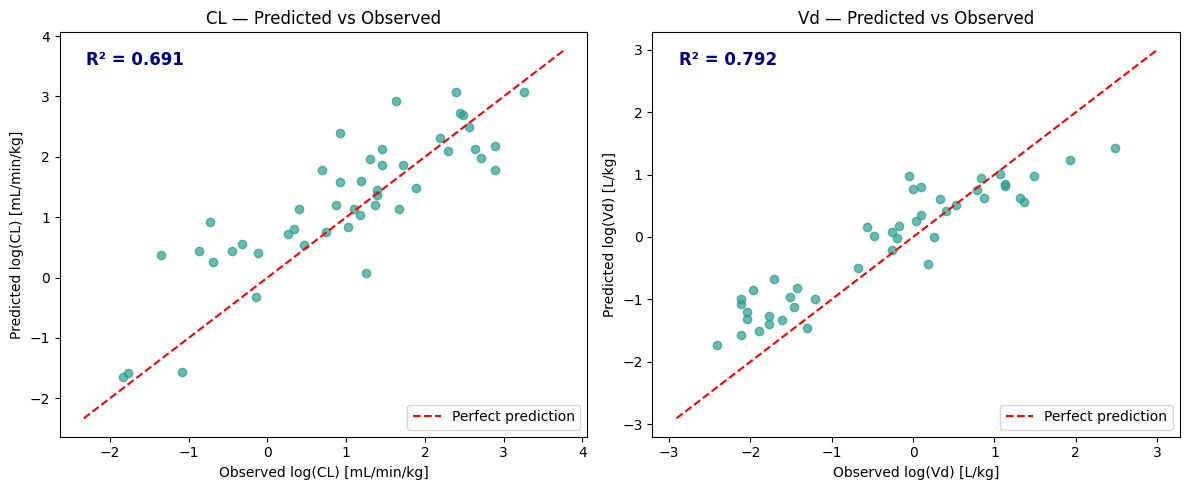

In [41]:


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CL — XGBoost
ax = axes[0]
ax.scatter(y_cl_eval, cl_preds_tuned, alpha=0.7, color='#2a9d8f')
lims = [min(y_cl_eval.min(), cl_preds_tuned.min()) - 0.5,
        max(y_cl_eval.max(), cl_preds_tuned.max()) + 0.5]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Observed log(CL) [mL/min/kg]')
ax.set_ylabel('Predicted log(CL) [mL/min/kg]')
ax.set_title('CL — Predicted vs Observed')
cl_r2 = r2_score(y_cl_eval, cl_preds_tuned)
ax.text(0.05, 0.92, f'R² = {cl_r2:.3f}', transform=ax.transAxes,
        fontsize=12, color='navy', fontweight='bold')
ax.legend()

# Vd — Random Forest
ax = axes[1]
ax.scatter(y_vd_eval, vd_preds, alpha=0.7, color='#2a9d8f')
lims = [min(y_vd_eval.min(), vd_preds.min()) - 0.5,
        max(y_vd_eval.max(), vd_preds.max()) + 0.5]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Observed log(Vd) [L/kg]')
ax.set_ylabel('Predicted log(Vd) [L/kg]')
ax.set_title('Vd — Predicted vs Observed')
vd_r2 = r2_score(y_vd_eval, vd_preds)
ax.text(0.05, 0.92, f'R² = {vd_r2:.3f}', transform=ax.transAxes,
        fontsize=12, color='navy', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('CL_Vd_predictions.png', dpi=150, bbox_inches='tight')
plt.show()